# 糖尿病病情进展预测

本 Notebook 对 sklearn 内置糖尿病数据集进行探索性分析、建模与评估，
使用线性回归和随机森林回归预测一年后病情进展指标。

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.datasets import load_diabetes
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error

sns.set(style="whitegrid")
plt.rcParams["font.sans-serif"] = ["SimHei"]
plt.rcParams["axes.unicode_minus"] = False

RANDOM_STATE = 42

In [2]:
diabetes = load_diabetes()
X = pd.DataFrame(diabetes.data, columns=diabetes.feature_names)
y = pd.Series(diabetes.target, name="target")

print("数据形状:", X.shape)
print("特征数量:", X.shape[1])
print("样本数量:", X.shape[0])
print("\n特征列表:", list(X.columns))
print("\n缺失值总数:", X.isnull().sum().sum())
print("\n目标变量统计:\n", y.describe())
X.head()

数据形状: (442, 10)
特征数量: 10
样本数量: 442

特征列表: ['age', 'sex', 'bmi', 'bp', 's1', 's2', 's3', 's4', 's5', 's6']

缺失值总数: 0

目标变量统计:
 count    442.000000
mean     152.133484
std       77.093005
min       25.000000
25%       87.000000
50%      140.500000
75%      211.500000
max      346.000000
Name: target, dtype: float64


,age,sex,bmi,bp,s1,s2,s3,s4,s5,s6
0,0.038076,0.050680,0.061696,0.021872,-0.044223,-0.034821,-0.043401,-0.002592,0.019907,-0.017646
1,-0.001882,-0.044642,-0.051474,-0.026328,-0.008449,-0.019163,0.074412,-0.039493,-0.068332,-0.092204
2,0.085299,0.050680,0.044451,-0.005670,-0.045599,-0.034194,-0.032356,-0.002592,0.002861,-0.025930
3,-0.089063,-0.044642,-0.011595,-0.036656,0.012191,0.024991,-0.036038,0.034309,0.022688,-0.009362
4,0.005383,-0.044642,-0.036385,0.021872,0.003935,0.015596,0.008142,-0.002592,-0.031988,-0.046641


/usr/local/lib/python3.13/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 30446 (\N{CJK UNIFIED IDEOGRAPH-76EE}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.13/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 26631 (\N{CJK UNIFIED IDEOGRAPH-6807}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.13/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 21464 (\N{CJK UNIFIED IDEOGRAPH-53D8}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.13/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 37327 (\N{CJK UNIFIED IDEOGRAPH-91CF}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.13/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 65288 (\N{FULLWIDTH LEFT PARENTHESIS}) missing from font(s) DejaVu Sans.
  fig.canvas

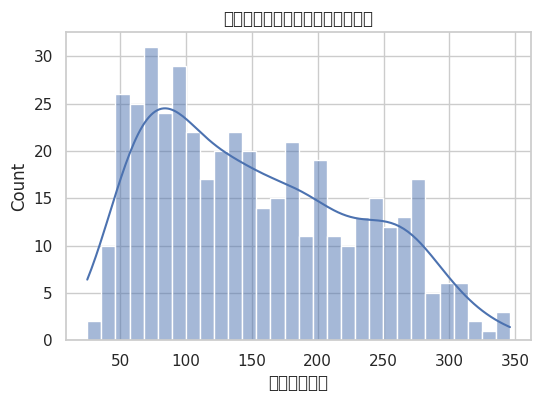

In [3]:
plt.figure(figsize=(6, 4))
sns.histplot(y, bins=30, kde=True, color="#4C72B0")
plt.title("目标变量（一年后病情进展）分布")
plt.xlabel("病情进展指标")
plt.show()

/tmp/ipykernel_1784/1982345690.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=corr_with_target.values, y=corr_with_target.index, palette="coolwarm")
/usr/local/lib/python3.13/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 21508 (\N{CJK UNIFIED IDEOGRAPH-5404}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.13/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 29983 (\N{CJK UNIFIED IDEOGRAPH-751F}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.13/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 29702 (\N{CJK UNIFIED IDEOGRAPH-7406}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.13/dist-packages/IPython/core/pylabtools.py:151: Use

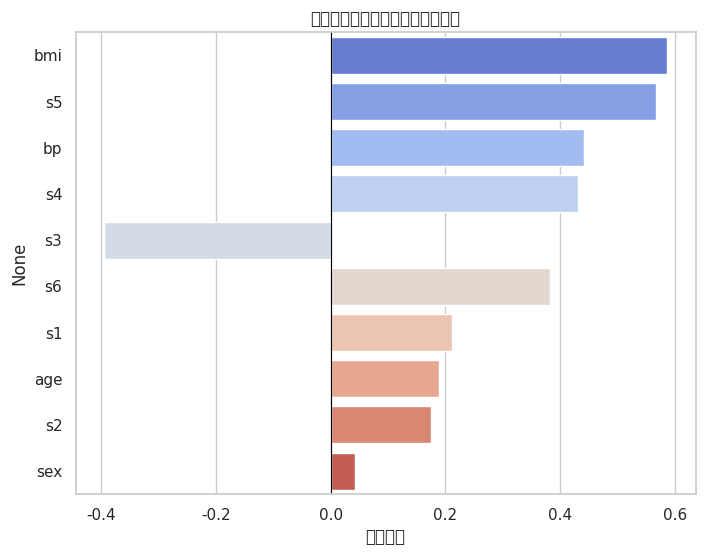

,0
bmi,0.586450
s5,0.565883
bp,0.441482
s4,0.430453
s3,-0.394789
s6,0.382483
s1,0.212022
age,0.187889
s2,0.174054
sex,0.043062


In [4]:
corr_with_target = X.corrwith(y).sort_values(key=lambda s: s.abs(), ascending=False)

plt.figure(figsize=(8, 6))
sns.barplot(x=corr_with_target.values, y=corr_with_target.index, palette="coolwarm")
plt.title("各生理指标与病情进展的相关系数")
plt.xlabel("相关系数")
plt.axvline(0, color="black", linewidth=0.8)
plt.show()

corr_with_target

/tmp/ipykernel_1784/8335824.py:10: UserWarning: Glyph 30149 (\N{CJK UNIFIED IDEOGRAPH-75C5}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_1784/8335824.py:10: UserWarning: Glyph 24773 (\N{CJK UNIFIED IDEOGRAPH-60C5}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_1784/8335824.py:10: UserWarning: Glyph 36827 (\N{CJK UNIFIED IDEOGRAPH-8FDB}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_1784/8335824.py:10: UserWarning: Glyph 23637 (\N{CJK UNIFIED IDEOGRAPH-5C55}) missing from font(s) DejaVu Sans.
  plt.tight_layout()


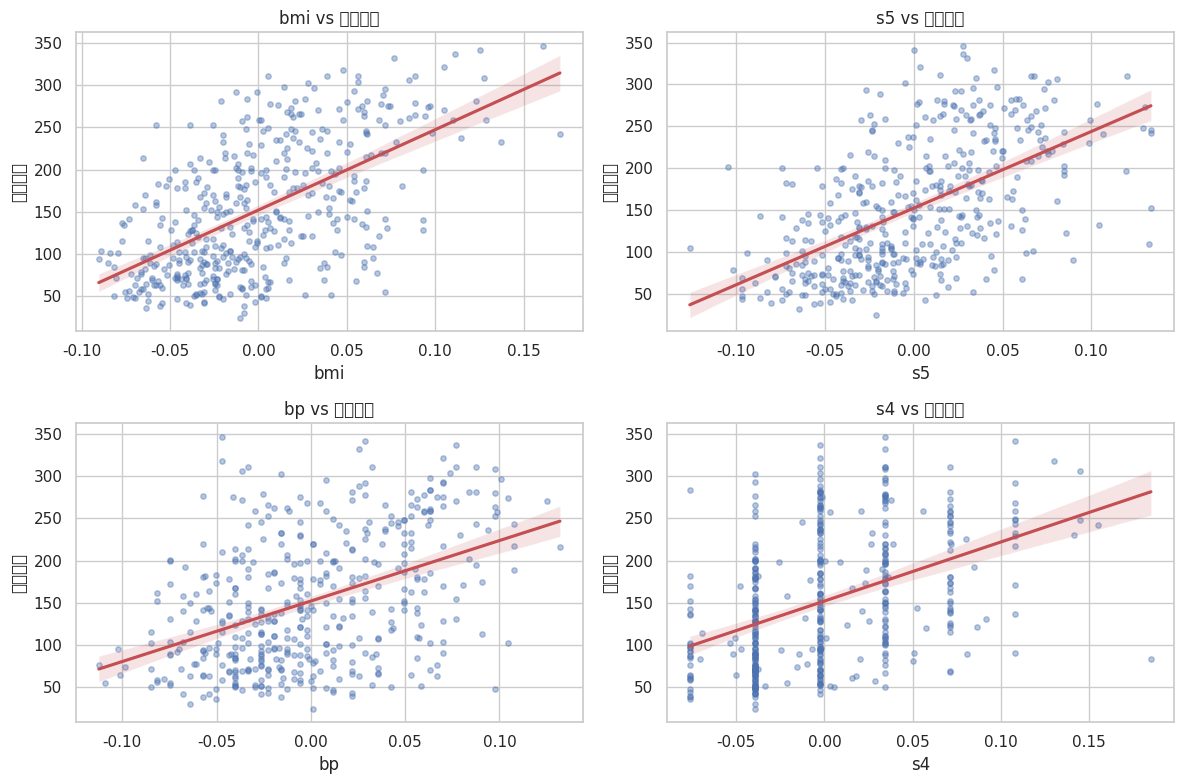

In [5]:
top_features = corr_with_target.head(4).index
fig, axes = plt.subplots(2, 2, figsize=(12, 8))
for ax, feat in zip(axes.ravel(), top_features):
    sns.regplot(x=X[feat], y=y, ax=ax,
                scatter_kws={"alpha": 0.4, "s": 15},
                line_kws={"color": "#C44E52"})
    ax.set_title(f"{feat} vs 病情进展")
    ax.set_xlabel(feat)
    ax.set_ylabel("病情进展")
plt.tight_layout()
plt.show()

In [6]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=RANDOM_STATE
)
print("训练集大小:", X_train.shape)
print("测试集大小:", X_test.shape)

训练集大小: (353, 10)
测试集大小: (89, 10)


In [7]:
lr = Pipeline([
    ("scaler", StandardScaler()),
    ("reg", LinearRegression())
])
lr.fit(X_train, y_train)
y_pred_lr = lr.predict(X_test)

rf = RandomForestRegressor(n_estimators=200, random_state=RANDOM_STATE)
rf.fit(X_train, y_train)
y_pred_rf = rf.predict(X_test)

In [8]:
def evaluate(name, y_true, y_pred):
    return {
        "Model": name,
        "R2": r2_score(y_true, y_pred),
        "MAE": mean_absolute_error(y_true, y_pred),
        "RMSE": np.sqrt(mean_squared_error(y_true, y_pred)),
    }

results = pd.DataFrame([
    evaluate("Linear Regression", y_test, y_pred_lr),
    evaluate("Random Forest", y_test, y_pred_rf),
]).set_index("Model")

results.round(4)

,R2,MAE,RMSE
Model,,,
Linear Regression,0.4526,42.7941,53.8534
Random Forest,0.4402,44.2761,54.4612


/tmp/ipykernel_1784/1753985555.py:9: UserWarning: Glyph 30495 (\N{CJK UNIFIED IDEOGRAPH-771F}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_1784/1753985555.py:9: UserWarning: Glyph 23454 (\N{CJK UNIFIED IDEOGRAPH-5B9E}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_1784/1753985555.py:9: UserWarning: Glyph 20540 (\N{CJK UNIFIED IDEOGRAPH-503C}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_1784/1753985555.py:9: UserWarning: Glyph 39044 (\N{CJK UNIFIED IDEOGRAPH-9884}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_1784/1753985555.py:9: UserWarning: Glyph 27979 (\N{CJK UNIFIED IDEOGRAPH-6D4B}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_1784/1753985555.py:9: UserWarning: Glyph 65306 (\N{FULLWIDTH COLON}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/usr/local/lib/python3.13/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 39044 (\N{CJK UNIFIE

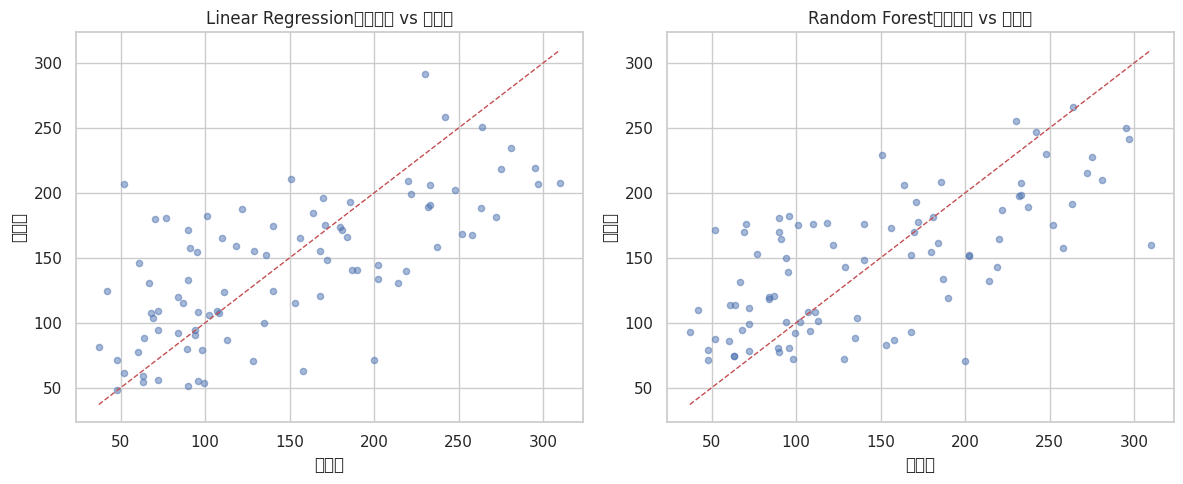

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
for ax, (name, y_pred) in zip(axes, [("Linear Regression", y_pred_lr), ("Random Forest", y_pred_rf)]):
    ax.scatter(y_test, y_pred, alpha=0.5, s=20, color="#4C72B0")
    lims = [min(y_test.min(), y_pred.min()), max(y_test.max(), y_pred.max())]
    ax.plot(lims, lims, "r--", linewidth=1)
    ax.set_title(f"{name}：预测值 vs 真实值")
    ax.set_xlabel("真实值")
    ax.set_ylabel("预测值")
plt.tight_layout()
plt.show()

/tmp/ipykernel_1784/3102265311.py:9: UserWarning: Glyph 39044 (\N{CJK UNIFIED IDEOGRAPH-9884}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_1784/3102265311.py:9: UserWarning: Glyph 27979 (\N{CJK UNIFIED IDEOGRAPH-6D4B}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_1784/3102265311.py:9: UserWarning: Glyph 20540 (\N{CJK UNIFIED IDEOGRAPH-503C}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_1784/3102265311.py:9: UserWarning: Glyph 27531 (\N{CJK UNIFIED IDEOGRAPH-6B8B}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_1784/3102265311.py:9: UserWarning: Glyph 24046 (\N{CJK UNIFIED IDEOGRAPH-5DEE}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_1784/3102265311.py:9: UserWarning: Glyph 65306 (\N{FULLWIDTH COLON}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_1784/3102265311.py:9: UserWarning: Glyph 22270 (\N{CJK UNIFIED IDEOGRAPH-56FE}) missing from fon

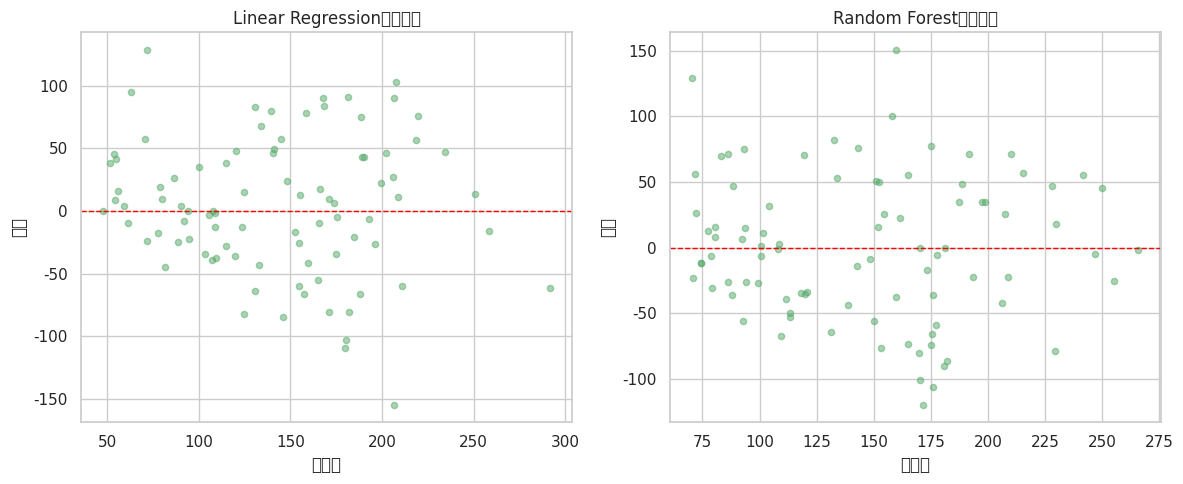

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
for ax, (name, y_pred) in zip(axes, [("Linear Regression", y_pred_lr), ("Random Forest", y_pred_rf)]):
    residuals = y_test - y_pred
    ax.scatter(y_pred, residuals, alpha=0.5, s=20, color="#55A868")
    ax.axhline(0, color="red", linestyle="--", linewidth=1)
    ax.set_title(f"{name}：残差图")
    ax.set_xlabel("预测值")
    ax.set_ylabel("残差")
plt.tight_layout()
plt.show()

/tmp/ipykernel_1784/2329622351.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=importances.values, y=importances.index, palette="viridis")
/usr/local/lib/python3.13/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 38543 (\N{CJK UNIFIED IDEOGRAPH-968F}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.13/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 26426 (\N{CJK UNIFIED IDEOGRAPH-673A}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.13/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 26862 (\N{CJK UNIFIED IDEOGRAPH-68EE}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.13/dist-packages/IPython/core/pylabtools.py:151: UserWarning: G

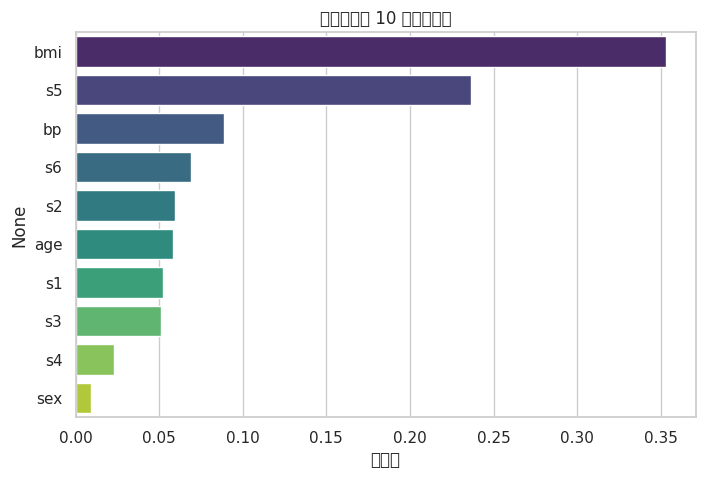

,0
bmi,0.353246
s5,0.236397
bp,0.088485
s6,0.068979
s2,0.059566
age,0.057964
s1,0.052122
s3,0.050881
s4,0.023055
sex,0.009305


In [11]:
importances = pd.Series(rf.feature_importances_, index=X.columns).sort_values(ascending=False).head(10)
plt.figure(figsize=(8, 5))
sns.barplot(x=importances.values, y=importances.index, palette="viridis")
plt.title("随机森林前 10 个重要特征")
plt.xlabel("重要性")
plt.show()

importances

## 结论

- 在该固定测试集上，线性回归的 R² 略高于随机森林，MAE 和 RMSE 也略低。
- 说明该数据集的目标变量与特征之间存在较强的线性关系，树模型的非线性拟合优势不明显。
- 特征重要性显示 `bmi`、`s5`（甘油三酯对数）和 `bp`（平均血压）对病情进展预测贡献较大。
- R² 约 0.45 说明仍有大量方差未被解释，模型仅具演示价值。

## 局限

- 数据集规模小（442 个样本），来源单一。
- 仅做一次固定划分，未做交叉验证或外部验证。
- 特征来自基线测量值，不等同于完整临床信息。
- 特征重要性表达模型关联，不代表因果关系或医学机制。
- 结果不能用于个人健康决策或临床诊断。